In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from matplotlib.ticker import MaxNLocator
import itertools


**DATA LOAD**

In [2]:
# Path to data files
DATA_PATH = '/content/export_data'

OUTPUT_MERGED = 'india_monthly_exports_merged.xlsx'
OUTPUT_ANALYSIS = 'india_monthly_exports_analysis.xlsx'

In [3]:
# all Excel files
all_files = sorted([f for f in os.listdir(DATA_PATH) if f.endswith('.xlsx')])
export_files = [f for f in all_files if 'india_' not in f.lower()]

In [4]:
# extracting month and year
file_data = []
for filename in export_files:
    parts = filename.replace('.xlsx', '').split('_')

    if len(parts) == 2:
        month_str, year_str = parts

        # Standardizing month names
        month_str = month_str.lower()
        if month_str == 'july':
            month_str = 'jul'
        elif month_str == 'june':
            month_str = 'jun'

        # Converting month to number
        month_map = {
            'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
            'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
        }

        if month_str in month_map:
            month_num = month_map[month_str]
            year = int(year_str)
            file_data.append({
                'filename': filename,
                'year': year,
                'month': month_num,
                'month_str': month_str.capitalize(),
                'date': pd.Timestamp(year=year, month=month_num, day=1)
            })


file_data = sorted(file_data, key=lambda x: x['date'])

print(f"\nRead {len(file_data)} files:")
from collections import Counter
year_counts = Counter([f['year'] for f in file_data])
print(f"\nFiles per year:")
for year in sorted(year_counts.keys()):
    print(f"  {year}: {year_counts[year]} files")


Read 96 files:

Files per year:
  2018: 12 files
  2019: 12 files
  2020: 12 files
  2021: 12 files
  2022: 12 files
  2023: 12 files
  2024: 12 files
  2025: 12 files


In [5]:
def country_name(country_name):
  if pd.isna(country_name):
        return None
        country = str(country_name).upper().strip()
        return country

all_data = []
load_errors = []


for file_info in file_data:
    try:
        # Read file
        filepath = os.path.join(DATA_PATH, file_info['filename'])
        df = pd.read_excel(filepath)
        df.columns = df.columns.str.strip().str.lower()

        # Cleaning export values
        df['Export_Value'] = pd.to_numeric(df['export'], errors='coerce')

        # Adding date information
        df['Year'] = file_info['year']
        df['Month'] = file_info['month']
        df['Month_Name'] = file_info['month_str']
        df['Date'] = file_info['date']
        df['Year_Month'] = f"{file_info['year']}-{file_info['month']:02d}"


        df_clean = df[['country', 'Export_Value', 'Year', 'Month', 'Month_Name',
                       'Date', 'Year_Month']].copy()
        df_clean.rename(columns={'country': 'Country'}, inplace=True)

        # Removing rows with missing country or export value
        df_clean = df_clean.dropna(subset=['Country', 'Export_Value'])

        all_data.append(df_clean)

        print(f"{file_info['month_str']} {file_info['year']}: {len(df_clean)} countries, Total: ${df_clean['Export_Value'].sum():.2f}")

    except:
        print(f"Error")

# Combining all data
print(f"\nCombining data from {len(all_data)} files")
df_all = pd.concat(all_data, ignore_index=True)
print(f"  Total rows: {len(df_all):,}")
print(f"  Unique countries: {df_all['Country'].nunique()}")
print(f"  Date range: {df_all['Date'].min().strftime('%b %Y')} to {df_all['Date'].max().strftime('%b %Y')}")
print(f"  Total months: {df_all['Year_Month'].nunique()}")

Jan 2018: 251 countries, Total: $25409.34
Feb 2018: 251 countries, Total: $26032.85
Mar 2018: 251 countries, Total: $29316.38
Apr 2018: 251 countries, Total: $25949.49
May 2018: 251 countries, Total: $28944.90
Jun 2018: 251 countries, Total: $27158.06
Jul 2018: 251 countries, Total: $22292.64
Aug 2018: 251 countries, Total: $23355.11
Sep 2018: 251 countries, Total: $27865.95
Oct 2018: 251 countries, Total: $26674.01
Nov 2018: 251 countries, Total: $26071.46
Dec 2018: 251 countries, Total: $27858.26
Jan 2019: 251 countries, Total: $26409.44
Feb 2019: 251 countries, Total: $26866.15
Mar 2019: 251 countries, Total: $32717.75
Apr 2019: 251 countries, Total: $26037.50
May 2019: 251 countries, Total: $29846.86
Jun 2019: 251 countries, Total: $25027.80
Jul 2019: 251 countries, Total: $26233.62
Aug 2019: 251 countries, Total: $25991.93
Sep 2019: 251 countries, Total: $26024.43
Oct 2019: 251 countries, Total: $26233.02
Nov 2019: 251 countries, Total: $25771.51
Dec 2019: 251 countries, Total: $2

**HANDLE MISSING VALUES & DATA QUALITY**

In [6]:
# looking for missing values
missing_check = df_all.isnull().sum()
print(missing_check[missing_check > 0])

if missing_check.sum() == 0:
    print("No missing values found")

# is there any extremely high values
high = df_all['Export_Value'].quantile(0.99)
outliers = df_all[df_all['Export_Value'] > high * 10]
if len(outliers) > 0:
    print(f"\n Found {len(outliers)} potential outliers")
    print("Top 5 outlier values:")
    print(outliers.nlargest(5, 'Export_Value')[['Country', 'Year_Month', 'Export_Value']])
else:
    print("\n No extreme outliers ")

Series([], dtype: int64)
No missing values found

 No extreme outliers 


In [7]:
# CREATE PIVOT TABLE
# Countries x Months x Export
pivot = df_all.pivot_table(
index='Country',
columns='Year_Month',
values='Export_Value',
aggfunc='sum',
fill_value=0
).round(2)
print(f"\nPivot table :")
print(pivot.head(5))
print(f"  Countries: {pivot.shape[0]}")
print(f"  Months: {pivot.shape[1]}")
# Add total column
pivot['TOTAL'] = pivot.sum(axis=1)


Pivot table :
Year_Month   2018-01  2018-02  2018-03  2018-04  2018-05  2018-06  2018-07  \
Country                                                                      
AFGHANISTAN    51.17    57.61    89.83    56.19    62.24    75.68    45.72   
ALBANIA         3.89     2.76     2.93     3.27     3.22     3.52     1.74   
ALGERIA        76.94    72.39   115.01    65.06    73.34    74.47    62.04   
AMERI SAMOA     0.00     0.00     0.00     0.00     0.01     0.00     0.05   
ANDORRA         0.02     0.04     0.01     0.01     0.08     0.00     0.00   

Year_Month   2018-08  2018-09  2018-10  ...  2025-03  2025-04  2025-05  \
Country                                 ...                              
AFGHANISTAN    65.62    58.21    44.98  ...    29.21    22.82    20.33   
ALBANIA         1.75     2.99     2.22  ...     8.50     7.17     7.89   
ALGERIA        49.94    90.25    80.09  ...   100.35    68.10    82.70   
AMERI SAMOA     0.03     0.00     0.01  ...     0.09     0.01     0.

# ***EXPORT SHARE & GROWTH RATE***

In [8]:
############ 1. CALCULATION FOR MONTHLY EXPORT SHARES

# Calculating monthly totals
monthly_totals = df_all.groupby('Year_Month')['Export_Value'].sum()

print(f"\nMonthly export totals (first 5 months):")
print(monthly_totals.head(5))

# Calculating shares for each country in each month
df_all['Monthly_Total'] = df_all['Year_Month'].map(monthly_totals)
df_all['Export_Share_%'] = (df_all['Export_Value'] / df_all['Monthly_Total'] * 100).round(4)

# Creating share pivot table
share_pivot = df_all.pivot_table(
    index='Country',
    columns='Year_Month',
    values='Export_Share_%',
    aggfunc='sum',
    fill_value=0
).round(4)



# Adding average share column
share_pivot['AVG_SHARE_%'] = share_pivot.mean(axis=1).round(5)

# Sort by average share
share_pivot = share_pivot.sort_values('AVG_SHARE_%', ascending=False)

print(f"\nTop 5 countries by average export share:")
print(share_pivot.head(5))

share_sums = share_pivot.drop(columns=['AVG_SHARE_%']).sum()
print(f"\nShare sum : ")
print(f"  Min: {share_sums.min():.2f}%")
print(f"  Max: {share_sums.max():.2f}%")
print(f"  Mean: {share_sums.mean():.2f}%")


Monthly export totals (first 5 months):
Year_Month
2018-01    25409.34
2018-02    26032.85
2018-03    29316.38
2018-04    25949.49
2018-05    28944.90
Name: Export_Value, dtype: float64

Top 5 countries by average export share:
Year_Month   2018-01  2018-02  2018-03  2018-04  2018-05  2018-06  2018-07  \
Country                                                                      
U S A        16.1117  15.1414  15.6050  15.8793  15.8001  15.0713  16.7613   
U ARAB EMTS   6.5228   8.5747   8.0178  10.0209  11.9693   9.2559   7.8927   
CHINA P RP    4.4285   4.6635   5.4391   5.0026   4.6214   5.0695   3.7229   
NETHERLAND    3.0644   2.6044   2.2521   1.8592   3.6548   2.4903   1.7104   
SINGAPORE     2.3317   3.5428   2.8711   2.2735   4.1944   3.6144   4.7673   

Year_Month   2018-08  2018-09  2018-10  ...  2025-04  2025-05  2025-06  \
Country                                 ...                              
U S A        16.1375  16.0860  16.8184  ...  21.8970  23.0424  23.6618   
U 

In [9]:
############### 2. CALCULATION FOR MONTHLY GROWTH RATES

growth_pivot = pivot.drop(columns=['TOTAL']).pct_change(axis=1) * 100
growth_pivot = growth_pivot.round(2)

# Calculating Month-over-month growth for each country
df_all['MoM Growth (%)'] = df_all.groupby('Country')['Export_Value'].pct_change() * 100
df_all['MoM Growth (%)'] = df_all['MoM Growth (%)'].round(2)


# Year-over-year growth
yoy_growth_list = []

for country in df_all['Country'].unique():
    country_data = df_all[df_all['Country'] == country].copy()
    country_data = country_data.sort_values('Date')

    # Calculate YoY growth (12 months lag , comparing a specific  months value with 12 months prior value)
    country_data['YoY_Growth_%'] = country_data['Export_Value'].pct_change(12) * 100

    yoy_growth_list.append(country_data)

df_with_yoy = pd.concat(yoy_growth_list, ignore_index=True)

top5 = pivot.nlargest(5, 'TOTAL')[['TOTAL']]
for idx, (country, row) in enumerate(top5.iterrows(), 1):
    print(f"  {idx}. {country:30s} ${row['TOTAL']:>12,.2f}M ({row['TOTAL']/pivot['TOTAL'].sum()*100:.2f}%)")

  1. U S A                          $  552,902.39M (17.91%)
  2. U ARAB EMTS                    $  242,128.10M (7.84%)
  3. CHINA P RP                     $  139,287.17M (4.51%)
  4. NETHERLAND                     $  118,591.52M (3.84%)
  5. SINGAPORE                      $   90,597.98M (2.94%)


In [18]:
from openpyxl import Workbook, load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.utils.dataframe import dataframe_to_rows

In [11]:
output_path = OUTPUT_ANALYSIS
writer = pd.ExcelWriter(output_path, engine='openpyxl')

#### Sheet 1: Export Values
pivot.to_excel(writer, sheet_name='Export Values', index=True)
print(" Sheet 1: Export Values")

#### Sheet 2: Export Shares
share_pivot.to_excel(writer, sheet_name='Export Shares (%)', index=True)
print("Sheet 2: Export Shares (%)")

#### Sheet 3 : date wise combined data
df_all_sorted = df_all.sort_values(['Date', 'Country'])
df_all_sorted.to_excel(writer, sheet_name='Long Format', index=False)
print("Sheet 2: Long Format")

#### Sheet 4: Monthly Totals
monthly_summary = df_all.groupby('Year_Month').agg({
    'Export_Value': 'sum',
    'Country': 'count'
}).rename(columns={'Export_Value': 'Total_Exports', 'Country': 'Num_Countries'})
monthly_summary['Avg_Export_Per_Country'] = (
    monthly_summary['Total_Exports'] / monthly_summary['Num_Countries']
).round(2)
monthly_summary.to_excel(writer, sheet_name='Monthly Totals', index=True)
print("Sheet 4: Monthly Totals")

#### Sheet 5: Month-over-Month Growth
growth_pivot.to_excel(writer, sheet_name='MoM Growth (%)', index=True)
print("Sheet 5: MoM Growth (%)")

#### Sheet 6: Country wise Statistics
country_stats = df_all.groupby('Country').agg({
    'Export_Value': ['mean', 'std', 'min', 'max', 'sum'],
    'Export_Share_%': 'mean',
    'Year_Month': 'count'
}).round(2)
country_stats.columns = ['Avg_Export', 'StdDev_Export', 'Min_Export',
                         'Max_Export', 'Total_Export', 'Avg_Share_%', 'Num_Months']
country_stats = country_stats.sort_values('Total_Export', ascending=False)
country_stats.to_excel(writer, sheet_name='Country_Stat', index=True)
print("Sheet 6: Country Statistics")

#### Sheet 7: Top 20 Countries
top_20_countries = pivot.nlargest(20, 'TOTAL').index.tolist()
df_top20 = df_all[df_all['Country'].isin(top_20_countries)].copy()
top20_pivot = df_top20.pivot_table(
    index='Country',
    columns='Year_Month',
    values='Export_Value',
    aggfunc='sum',
    fill_value=0
)
top20_pivot['TOTAL'] = top20_pivot.sum(axis=1)
top20_pivot = top20_pivot.sort_values('TOTAL', ascending=False)
top20_pivot.to_excel(writer, sheet_name='Top Countries', index=True)
print("Sheet 7: Top Countries")
writer.close()
print(f" saved at {output_path}")

 Sheet 1: Export Values
Sheet 2: Export Shares (%)
Sheet 2: Long Format
Sheet 4: Monthly Totals
Sheet 5: MoM Growth (%)
Sheet 6: Country Statistics
Sheet 7: Top Countries
 saved at india_monthly_exports_analysis.xlsx


**VISUALIZATION 1.**

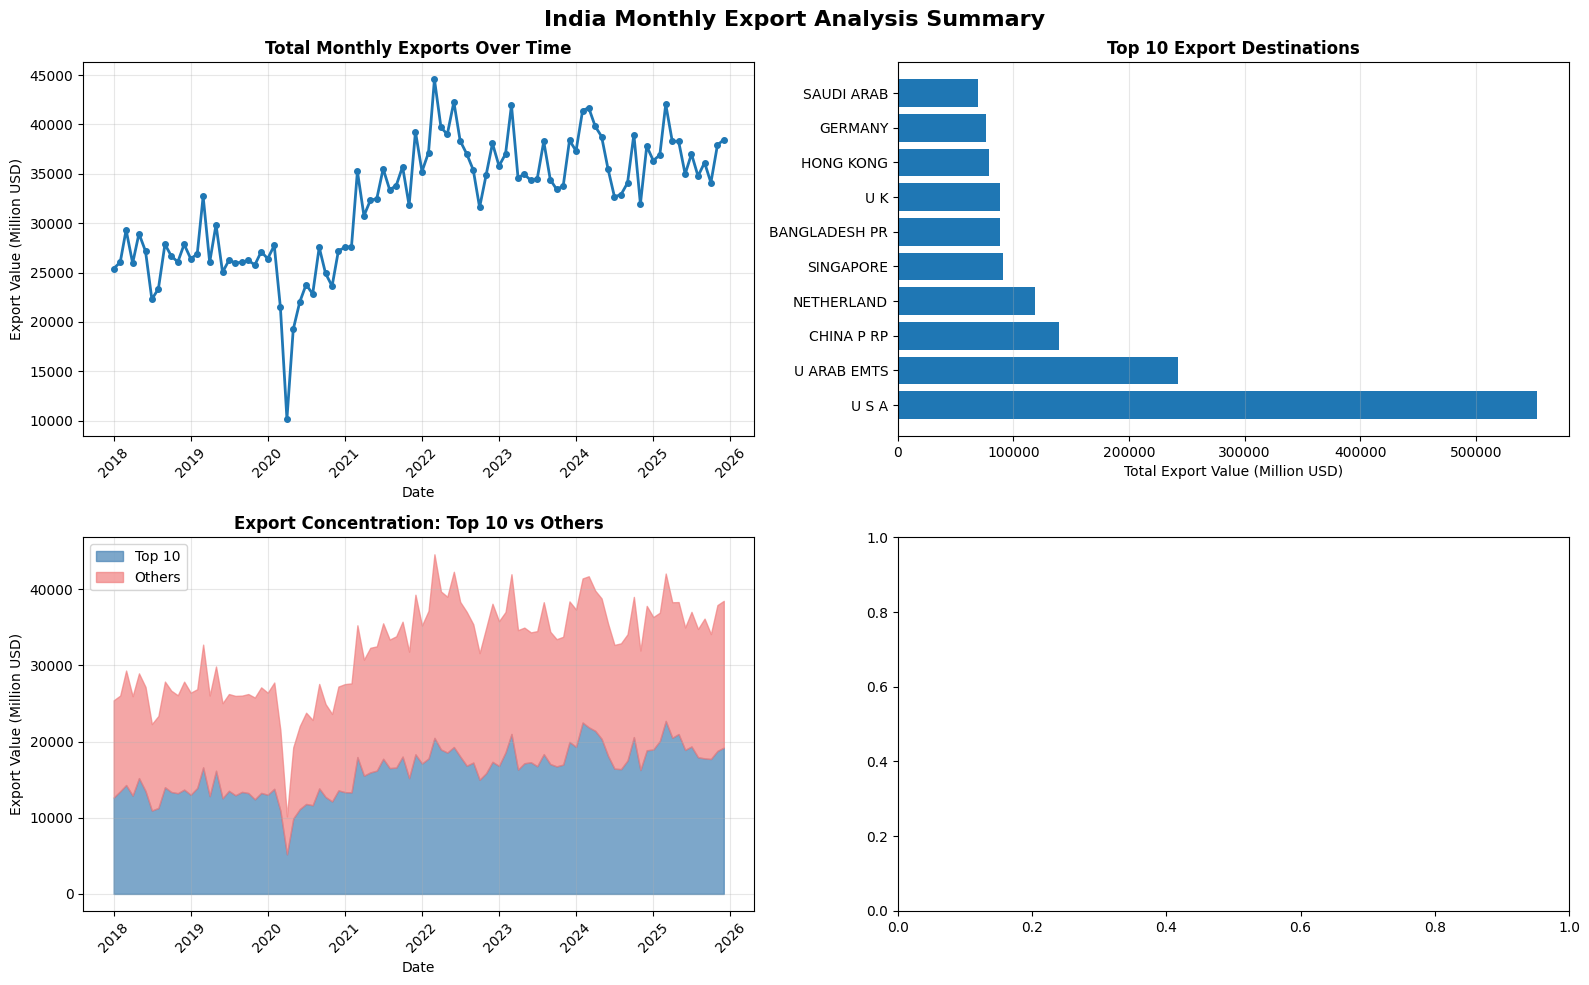

In [12]:
# Creating the directory
os.makedirs('visualizations', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('India Monthly Export Analysis Summary', fontsize=16, fontweight='bold')

# Plot 1: Monthly total exports
ax1 = axes[0, 0]
monthly_totals_sorted = monthly_totals.sort_index()
dates = pd.to_datetime(monthly_totals_sorted.index + '-01')
ax1.plot(dates, monthly_totals_sorted.values, marker='o', linewidth=2, markersize=4)
ax1.set_title('Total Monthly Exports Over Time', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Export Value (Million USD)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Top 10 countries
ax2 = axes[0, 1]
top10 = pivot.nlargest(10, 'TOTAL')['TOTAL']
ax2.barh(range(len(top10)), top10.values)
ax2.set_yticks(range(len(top10)))
ax2.set_yticklabels(top10.index)
ax2.set_title('Top 10 Export Destinations', fontweight='bold')
ax2.set_xlabel('Total Export Value (Million USD)')
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: Export concentration (top 10 vs rest)
ax3 = axes[1, 0]
top10_countries = pivot.nlargest(10, 'TOTAL').index
monthly_top10 = df_all[df_all['Country'].isin(top10_countries)].groupby('Year_Month')['Export_Value'].sum()
monthly_rest = df_all[~df_all['Country'].isin(top10_countries)].groupby('Year_Month')['Export_Value'].sum()

dates4 = pd.to_datetime(monthly_top10.sort_index().index + '-01')
ax3.fill_between(dates4, 0, monthly_top10.sort_index().values, alpha=0.7, label='Top 10', color='steelblue')  # ← ax4 → ax3
ax3.fill_between(dates4, monthly_top10.sort_index().values,                                                   # ← ax4 → ax3
                 monthly_top10.sort_index().values + monthly_rest.sort_index().values,
                 alpha=0.7, label='Others', color='lightcoral')
ax3.set_title('Export Concentration: Top 10 vs Others', fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Export Value (Million USD)')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('visualizations/monthly_export_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ***VOLATILITY & RISK MATRIX***

In [13]:
input_file = 'india_monthly_exports_analysis.xlsx'
df = pd.read_excel(input_file, sheet_name='Long Format')

##### loading MoM Growth again
if 'MoM Growth (%)' in df.columns:
    growth_col = 'MoM Growth (%)'
    print("data loaded")
else:
    print("not found")

##### Volatility matrix
print("CALCULATING VOLATILITY METRICS")

volatility_metrics = []

for country in df['Country'].unique():
    country_data = df[df['Country'] == country].copy().sort_values('Date')

    export_values = country_data['Export_Value'].values
    growth_values = country_data[growth_col].values

    # Non-zero exports
    non_zero_mask = (export_values > 0) & (~np.isnan(export_values))
    non_zero_exports = export_values[non_zero_mask]

    # Valid growth rates
    valid_growth = []
    for i in range(1, len(export_values)):
        if export_values[i] > 0 and export_values[i-1] > 0 and not np.isnan(growth_values[i]):
            valid_growth.append(growth_values[i])

    growth_rates = np.array(valid_growth) if len(valid_growth) > 0 else np.array([0])

    total_months = len(country_data)
    non_zero_months = len(non_zero_exports)
    valid_growth_months = len(growth_rates) if len(valid_growth) > 0 else 0


    ####### Calculate metrics
    if len(growth_rates) > 0 and valid_growth_months > 0:
        avg_growth = np.mean(growth_rates)
    else:
        avg_growth = 0

    if len(growth_rates) > 1:
        std_growth = np.std(growth_rates, ddof=1)
    else:
        std_growth = 0

    if abs(avg_growth) > 0.01 and std_growth > 0:
        cv = (std_growth / abs(avg_growth)) * 100
    else:
        cv = 0

    if len(growth_rates) > 0:
        growth_range = np.max(growth_rates) - np.min(growth_rates)
    else:
        growth_range = 0

    if len(growth_rates) > 0:
        negative_months = np.sum(growth_rates < 0)
        pct_negative = (negative_months / len(growth_rates)) * 100
    else:
        negative_months = 0
        pct_negative = 0

    if len(growth_rates) > 1:
        cumulative = np.cumprod(1 + growth_rates/100)
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (cumulative - running_max) / running_max * 100
        max_drawdown = np.min(drawdown)
    else:
        max_drawdown = 0

    if len(non_zero_exports) > 0:
        avg_export = np.mean(non_zero_exports)
    else:
        avg_export = 0

    ######## Volatility Score
    std_score = min(std_growth / 50 * 100, 100) if std_growth > 0 else 0
    cv_score = min(abs(cv) / 200 * 100, 100) if cv > 0 else 0
    range_score = min(growth_range / 200 * 100, 100) if growth_range > 0 else 0
    negative_score = pct_negative
    drawdown_score = min(abs(max_drawdown) / 50 * 100, 100) if max_drawdown != 0 else 0

    volatility_score = (
        std_score * 0.30 +
        cv_score * 0.20 +
        range_score * 0.20 +
        negative_score * 0.15 +
        drawdown_score * 0.15
    )

    ######## Risk Classification (based on volatility score)
    if volatility_score < 20:
        risk_class, risk_level = "Very Low Risk", 1
    elif volatility_score < 40:
        risk_class, risk_level = "Low Risk", 2
    elif volatility_score < 60:
        risk_class, risk_level = "Medium Risk", 3
    elif volatility_score < 80:
        risk_class, risk_level = "High Risk", 4
    else:
        risk_class, risk_level = "Very High Risk", 5


    data_completeness = (non_zero_months / total_months) * 100 if total_months > 0 else 0
    #data completeness represent percentage of non zero export months

    volatility_metrics.append({
        'Country': country,
        'Total_Months': total_months,
        'Non_Zero_Months': non_zero_months,
        'Valid_Growth_Months': valid_growth_months,
        'Data_Completeness_%': round(data_completeness, 3),
        'Avg_MoM_Growth_%': round(avg_growth, 2),
        'StdDev_Growth': round(std_growth, 2),
        'Coeff_of_Variation': round(cv, 2),
        'Growth_Range_%': round(growth_range, 2),
        'Negative_Months': int(negative_months),
        'Pct_Negative_%': round(pct_negative, 2),
        'Max_Drawdown_%': round(max_drawdown, 2),
        'Avg_Export_Value': round(avg_export, 2),
        'Volatility_Score': round(volatility_score, 2),
        'Risk_Class': risk_class,
        'Risk_Level': risk_level
    })

volatility_df = pd.DataFrame(volatility_metrics).sort_values('Volatility_Score', ascending=False)


print("\nBy Data Completeness(non zero exports months):")
excellent = len(volatility_df[(volatility_df['Data_Completeness_%'] > 95) &
                              (volatility_df['Data_Completeness_%'] <= 100)])
good = len(volatility_df[(volatility_df['Data_Completeness_%'] > 80) &
                         (volatility_df['Data_Completeness_%'] <= 95)])
fair = len(volatility_df[(volatility_df['Data_Completeness_%'] > 50) &
                         (volatility_df['Data_Completeness_%'] <= 80)])
poor = len(volatility_df[(volatility_df['Data_Completeness_%'] > 20) &
                         (volatility_df['Data_Completeness_%'] <= 50)])
very_poor = len(volatility_df[(volatility_df['Data_Completeness_%'] > 0) &
                              (volatility_df['Data_Completeness_%'] <= 20)])
no_exports = len(volatility_df[volatility_df['Data_Completeness_%'] == 0])

print(f"  Excellent (95-100%):      {excellent:3d} countries")
print(f"  Good (80-95%):            {good:3d} countries")
print(f"  Fair (50-80%):            {fair:3d} countries")
print(f"  Poor (20-50%):            {poor:3d} countries")
print(f"  Very Poor (0-20%):        {very_poor:3d} countries")
print(f"  No Exports (0%):          {no_exports:3d} countries")


print("RISK DISTRIBUTION")

risk_categories = [
    ('Very High Risk', 5, 'red'),
    ('High Risk', 4, 'orange'),
    ('Medium Risk', 3, 'yellow'),
    ('Low Risk', 2, 'green'),
    ('Very Low Risk', 1, 'dark_green')
]

for risk_name, risk_level, color in risk_categories:
    countries = volatility_df[volatility_df['Risk_Class'] == risk_name]
    count = len(countries)
    pct = (count/len(volatility_df)*100) if len(volatility_df) > 0 else 0
    print(f"{risk_name.upper()}: {count} countries ({pct:.1f}%)")

####### Sort by volatility score descending
    if count > 0:
        countries_sorted = countries.sort_values('Volatility_Score', ascending=False)

         # Show top 5 for each category
        display_count = min(5, count)

        print(f"\nTop {display_count} countries by volatility score :")
        for idx, (_, row) in enumerate(countries_sorted.head(display_count).iterrows(), 1):
            print(f"{idx:2d}. {row['Country']:30s} | Score: {row['Volatility_Score']:6.2f} | "
                  f"Avg Export: ${row['Avg_Export_Value']:>10,.2f}M | "
                  f"Completeness: {row['Data_Completeness_%']:>6.1f}%")



        # If more than 10 country in each category
        if count > 10:
            print(f"\n & {count - 10} more countries in this category")

data loaded
CALCULATING VOLATILITY METRICS

By Data Completeness(non zero exports months):
  Excellent (95-100%):      199 countries
  Good (80-95%):              7 countries
  Fair (50-80%):              7 countries
  Poor (20-50%):              8 countries
  Very Poor (0-20%):         23 countries
  No Exports (0%):            7 countries
RISK DISTRIBUTION
VERY HIGH RISK: 170 countries (67.7%)

Top 5 countries by volatility score :
 1. SINT MAARTEN (DUTCH PART)      | Score:  95.92 | Avg Export: $      0.10M | Completeness:   14.6%
 2. ANTARTICA                      | Score:  93.57 | Avg Export: $      0.12M | Completeness:   18.8%
 3. LESOTHO                        | Score:  93.53 | Avg Export: $      1.80M | Completeness:  100.0%
 4. MARTINIQUE                     | Score:  93.39 | Avg Export: $      0.41M | Completeness:   99.0%
 5. PORTUGAL                       | Score:  93.37 | Avg Export: $     78.59M | Completeness:  100.0%

 & 160 more countries in this category
HIGH RISK: 5

In [19]:
######## Excel
output_file = 'india_monthly_exports_analysis.xlsx'

book = load_workbook(input_file)
sheet_name = 'Volatility & Risk'

ws = book.create_sheet(sheet_name, 0)

# Headers
header_fill = PatternFill(start_color='C65911', end_color='C65911', fill_type='solid')
header_font = Font(bold=True, color='FFFFFF', size=11)

for col_idx, header in enumerate(volatility_df.columns, 1):
    cell = ws.cell(row=1, column=col_idx, value=header)
    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = Alignment(horizontal='center', vertical='center')

# Data
for row_idx, (_, row) in enumerate(volatility_df.iterrows(), 2):
    for col_idx, value in enumerate(row, 1):
        ws.cell(row=row_idx, column=col_idx, value=value)

# Color-code Risk_Class
risk_col_idx = list(volatility_df.columns).index('Risk_Class') + 1
risk_colors = {
    'Very High Risk': 'FF0000',
    'High Risk': 'FFC000',
    'Medium Risk': 'FFFF00',
    'Low Risk': '92D050',
    'Very Low Risk': '00B050'
}

for row_idx in range(2, ws.max_row + 1):
    risk = ws.cell(row=row_idx, column=risk_col_idx).value
    if risk in risk_colors:
        ws.cell(row=row_idx, column=risk_col_idx).fill = PatternFill(
            start_color=risk_colors[risk], end_color=risk_colors[risk], fill_type='solid')
        ws.cell(row=row_idx, column=risk_col_idx).font = Font(bold=True)

# Auto-width
for col_idx in range(1, len(volatility_df.columns) + 1):
    ws.column_dimensions[get_column_letter(col_idx)].width = 18

ws.freeze_panes = 'B2'

book.save(output_file)
print(f" saved: {output_file}")
print(f" Sheet: '{sheet_name}'")

 saved: india_monthly_exports_analysis.xlsx
 Sheet: 'Volatility & Risk'


**VISUALIZATION 2.**

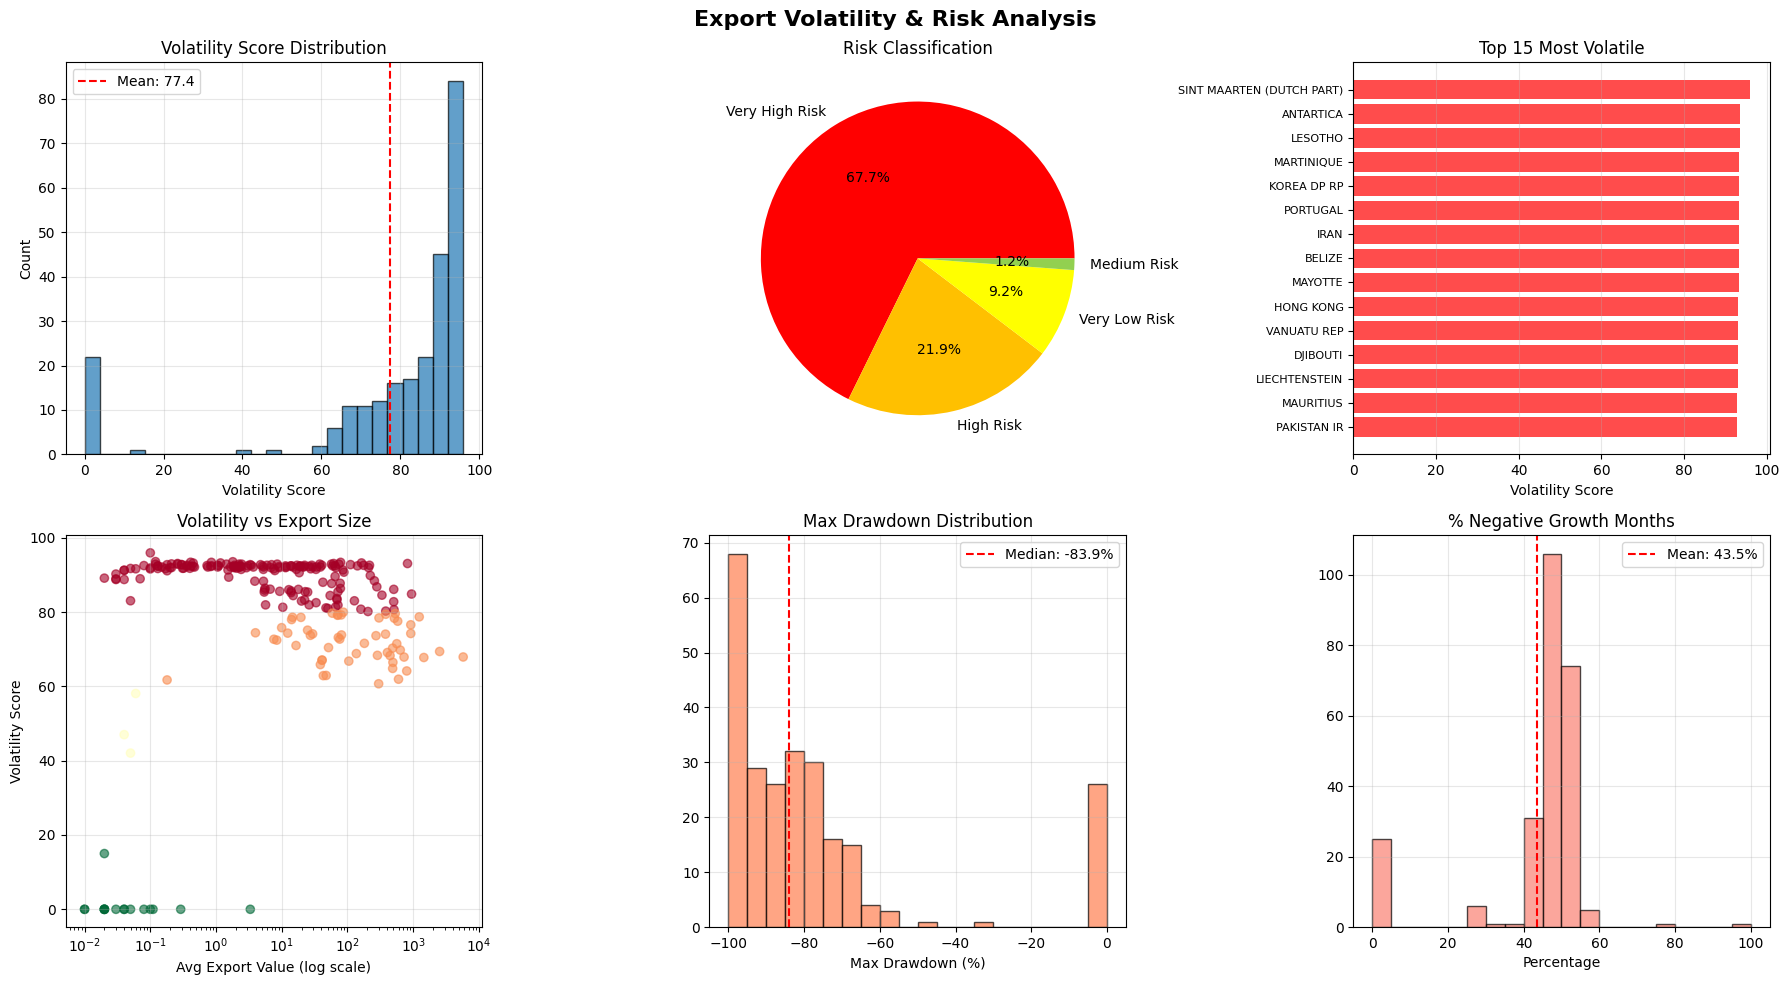

In [20]:
# Risk visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Export Volatility & Risk Analysis', fontsize=16, fontweight='bold')

# Volatility distribution
axes[0, 0].hist(volatility_df['Volatility_Score'], bins=25, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(volatility_df['Volatility_Score'].mean(), color='red', linestyle='--',
                   label=f'Mean: {volatility_df["Volatility_Score"].mean():.1f}')
axes[0, 0].set_title('Volatility Score Distribution')
axes[0, 0].set_xlabel('Volatility Score')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Risk classification
risk_counts = volatility_df['Risk_Class'].value_counts()
axes[0, 1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
               colors=['#FF0000', '#FFC000', '#FFFF00', '#92D050', '#00B050'][:len(risk_counts)])
axes[0, 1].set_title('Risk Classification')

# Top 15 volatile
top15 = volatility_df.head(15).sort_values('Volatility_Score')
axes[0, 2].barh(range(len(top15)), top15['Volatility_Score'], color='red', alpha=0.7)
axes[0, 2].set_yticks(range(len(top15)))
axes[0, 2].set_yticklabels(top15['Country'], fontsize=8)
axes[0, 2].set_title('Top 15 Most Volatile')
axes[0, 2].set_xlabel('Volatility Score')
axes[0, 2].grid(True, alpha=0.3, axis='x')

# Volatility vs Size
axes[1, 0].scatter(volatility_df['Avg_Export_Value'], volatility_df['Volatility_Score'],
                   c=volatility_df['Risk_Level'], cmap='RdYlGn_r', alpha=0.6)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Volatility vs Export Size')
axes[1, 0].set_xlabel('Avg Export Value (log scale)')
axes[1, 0].set_ylabel('Volatility Score')
axes[1, 0].grid(True, alpha=0.3)

# Max drawdown
axes[1, 1].hist(volatility_df['Max_Drawdown_%'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].axvline(volatility_df['Max_Drawdown_%'].median(), color='red', linestyle='--',
                   label=f'Median: {volatility_df["Max_Drawdown_%"].median():.1f}%')
axes[1, 1].set_title('Max Drawdown Distribution')
axes[1, 1].set_xlabel('Max Drawdown (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Negative months
axes[1, 2].hist(volatility_df['Pct_Negative_%'], bins=20, edgecolor='black', alpha=0.7, color='salmon')
axes[1, 2].axvline(volatility_df['Pct_Negative_%'].mean(), color='red', linestyle='--',
                   label=f'Mean: {volatility_df["Pct_Negative_%"].mean():.1f}%')
axes[1, 2].set_title('% Negative Growth Months')
axes[1, 2].set_xlabel('Percentage')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/volatility_risk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()